# 💳 TTTC2453 Machine Learning — Final Group Project
## ML Pipeline
## D6 - Credit Card Fraud / Kaggle / Imbalanced Classification — Extreme imbalance (0.17%), SMOTE / weighting, precision-recall trade-off
## Pipeline Stages
  1. Stage 0  — Data Audit, Cleaning & EDA
  2. Stage 0b — Imbalance Handling
  3. Stage A  — Classical / Baseline Model (Logistic Regression)
  4. Stage B  — Ensemble / Intermediate Model (Gradient Boosting)
  5. Stage C  — Deep Learning Model (MLP)

# Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
print('Environment Ready ✓')

Environment Ready ✓


In [ ]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Shape: ", df.shape)
print("\nDtypes:")
print(df.dtypes)
df.head()

Shape:  (284807, 31)

Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Missing Value Audit

In [ ]:
print('=== DATA TYPES & NULLS ===')
print(df.info())

print('\n=== DESCRIPTIVE STATISTICS ===')
df.describe(include='all').round(2)

=== DATA TYPES & NULLS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-nu

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(2),
    'Strategy': ['None required' if missing[col] == 0
                 else 'Drop / Impute' for col in df.columns]
}).sort_values(by='Missing Count', ascending=False)

missing_table.loc['TOTAL'] = [missing.sum(),
                               round(missing.sum() / len(df) * 100, 2),
                               '']

if missing.sum() == 0:
    print("No missing values found in the dataset.")
    print("Strategy: No imputation required.")
else:
    print("Missing values found:")
    print(missing_table[missing_table['Missing Count'] > 0])

No missing values found in the dataset.
Strategy: No imputation required.


*### Interpretation*

A check was perform across all features of Credit Card Fraud dataset. It confirms that no missing or null values are present in any column. Therefore, no amputation needed.

# Check Duplicates

In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

if duplicates > 0:
  df = df.drop_duplicates().reset_index(drop=True)
  print("After dropping duplicates:", df.shape)
else:
  print("No duplicated values found in dataset")

Duplicate rows: 1081
After dropping duplicates: (283726, 31)


# Class Distribution

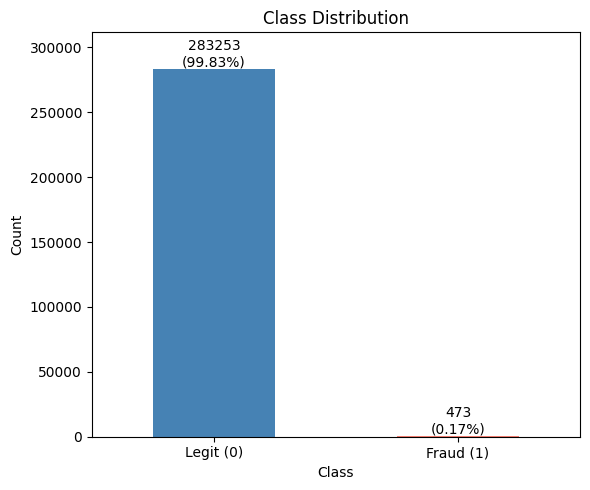

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

counts = df['Class'].value_counts()
percentages = df['Class'].value_counts(normalize=True).mul(100).round(2)

counts.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])

ax.set_title('Class Distribution')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.1)  # add graph y-axis headroom

for p, pct in zip(ax.patches, percentages):
    ax.annotate(f'{int(p.get_height())}\n({pct}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

*### Interpretation*

The bar chart shows raw count and percentage of the two classes, one for legitimate transactions (Class 0) and one for fraud (Class 1). Based on the visual, the dataset is severely imbalanced, 99.83% legitimate vs 0.17% fraud. If a classifier predicts legit for every transaction, it would score 99.83% accuracy yet catch zero fraud transaction. Hence, AUC-PR and recall will be used instead of accuracy.

# Outlier Analysis

In [ ]:
# Step 1 — IQR Outlier Table (on features only, excluding the target)
features_only = df.drop(columns=['Class'])

Q1 = features_only.quantile(0.25)
Q3 = features_only.quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((features_only < (Q1 - 1.5 * IQR)) | (features_only > (Q3 + 1.5 * IQR))).sum()
outlier_pct = (outlier_count / len(features_only) * 100).round(2)

outlier_table = pd.DataFrame({
    'Outlier Count': outlier_count,
    'Outlier %': outlier_pct,
    'Strategy': ['Keep' if outlier_count[col] > 0 else 'N/A' for col in features_only.columns]
}).sort_values('Outlier Count', ascending=False)

print('=== OUTLIER ANALYSIS ===')
print(outlier_table[outlier_table['Outlier Count'] > 0])

# Step 2 — Correlation with target
print('\n=== FEATURE CORRELATION WITH CLASS ===')
corr = df.select_dtypes(include='number').corr()['Class'].abs().sort_values(ascending=False)
print(corr)

# Step 3 — Identify top features to focus on
top_features = corr[1:6].index.tolist()  # top 5 excluding Class itself
print(f'\nTop features to focus on: {top_features}')

=== OUTLIER ANALYSIS ===
        Outlier Count  Outlier % Strategy
V27             38799      13.67     Keep
Amount          31685      11.17     Keep
V28             30094      10.61     Keep
V20             27553       9.71     Keep
V8              23904       8.43     Keep
V6              22886       8.07     Keep
V23             18467       6.51     Keep
V12             15282       5.39     Keep
V21             14401       5.08     Keep
V14             14060       4.96     Keep
V2              13390       4.72     Keep
V5              12221       4.31     Keep
V4              11094       3.91     Keep
V19             10150       3.58     Keep
V10              9345       3.29     Keep
V7               8839       3.12     Keep
V9               8199       2.89     Keep
V16              8180       2.88     Keep
V18              7468       2.63     Keep
V17              7353       2.59     Keep
V1               6948       2.45     Keep
V26              5665       2.00     Keep
V25      

*### Interpretation*

Any transaction that are rare and significantly different from 'normal' behaviour can be flag as fraud transaction. Using outlier analysis, data points that exist in 'empty spaces' where legitimate transaction rarely go will be looked at, because fraud is an anomalous behaviour. Therefore, by retaining outliers, the model is given full distribution and is expected to learn the boundary between rare but legitimate transaction and fraudulent transaction.



In [ ]:
# Check Amount distribution for fraud vs legit
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


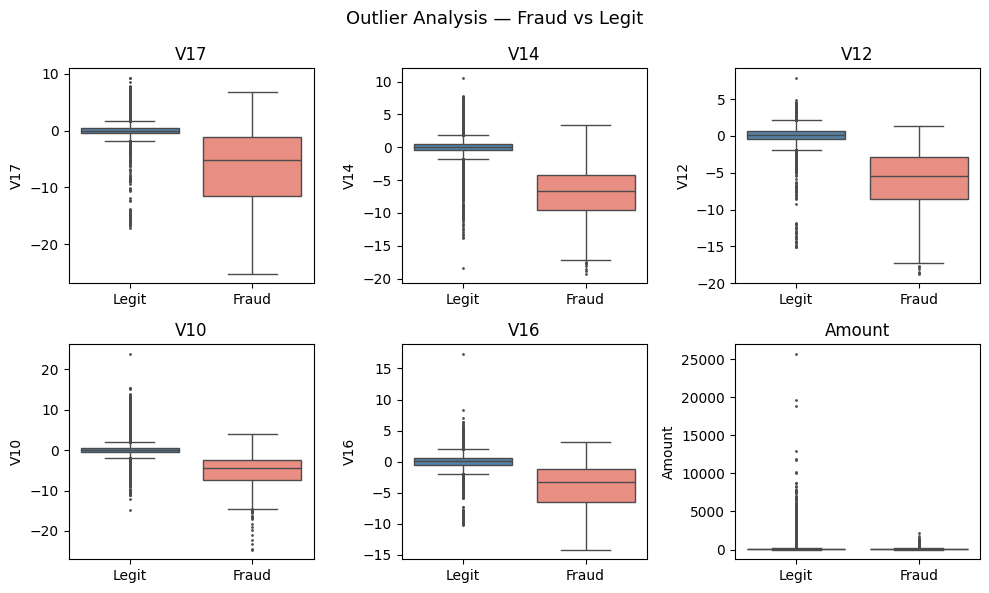

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))  # ← 2 rows, 3 cols
axes = axes.flatten()                               # ← flatten to loop easily

top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'Amount']

for i, col in enumerate(top_features):
    sns.boxplot(x=df['Class'].astype(str), y=df[col], ax=axes[i],
                palette={'0': 'steelblue', '1': 'salmon'},
                flierprops=dict(marker='o', markersize=1))
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Legit', 'Fraud'])
    axes[i].set_xlabel('')

plt.suptitle('Outlier Analysis — Fraud vs Legit', fontsize=13)
plt.tight_layout()
plt.show()

*### Interpretation*

The box plot panel of top features by class (Legit vs Fraud) that reveal distinct separation between the classes. The fraud class is consistently shifted relative to legit class. However, the degree of separation varies. Some features show fraud and legit class barely overlap, while others show considerable amount of overlapping. No single feature provides a clean separation between fraud and legitimate transaction on its own. Therefore, the model must combine many weak and moderate signal, because perfect separation is impossible. Some fraud transaction will sit inside the legitimate distribution and be missed by any classifier.

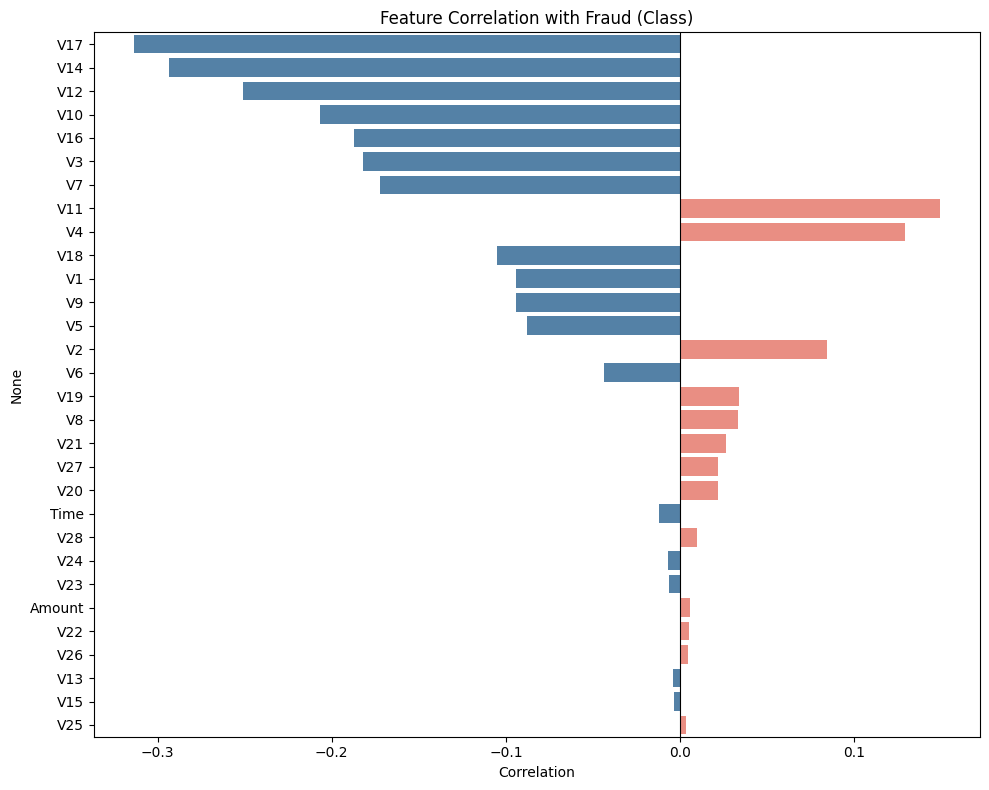

In [ ]:
# Only show correlation with Class, sorted
class_corr = df.corr()['Class'].drop('Class')
class_corr = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
colors=['salmon' if v > 0 else 'steelblue' for v in class_corr.values]
sns.barplot(x=class_corr.values, y=class_corr.index,
            palette=colors, hue=class_corr.index, legend=False)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

*### Interpretation*

The Correlation Bar Chart shows the overview of the linear correlation between each feature and the fraud class. The correlation are uniformly modest in magnitude, with the strongest features has -0.3 correlation with fraud class. No single feature acts as a perfect predictor for fraud. Because of this, five features with largest correlation, which are V17, V14, V12, V10, and V16, were selected since they provide clearest visual contrast between classes.

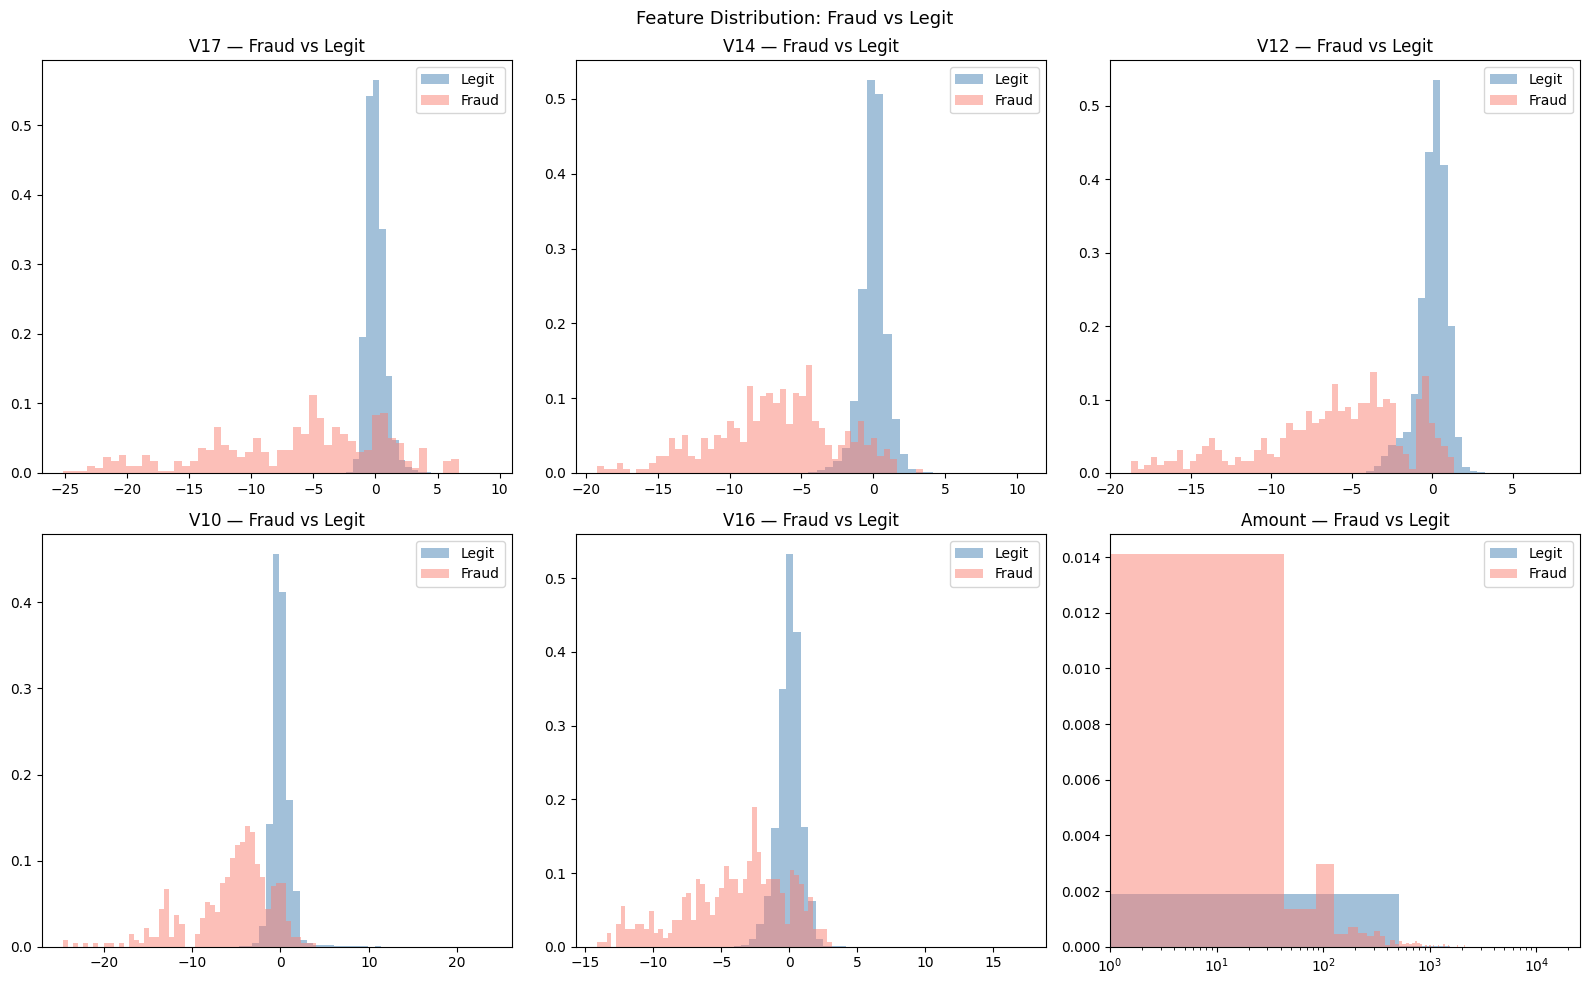

In [ ]:
# Shows how top features differ between fraud and legit
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'Amount']

for i, col in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][col], bins=50, alpha=0.5,
                 color='steelblue', label='Legit', density=True)  # ← density=True
    axes[i].hist(df[df['Class']==1][col], bins=50, alpha=0.5,
                 color='salmon', label='Fraud', density=True)     # ← density=True
    axes[i].set_title(f'{col} — Fraud vs Legit')
    axes[i].legend()

    if col == 'Amount':
      axes[i].set_xscale('log')               # shows better visualization on amount graph
      axes[i].set_xlim(1, df['Amount'].max()) # avoid log(0)

plt.suptitle('Feature Distribution: Fraud vs Legit', fontsize=13)
plt.tight_layout()
plt.show()

*### Interpretation*

This Density Histogram grid compares the shapes between Fraud and Legit class by rescaling the y-axis. y-axis shows probability density which is total area under each coloured domain equals to 1. x-axis represents the component score, which centered at 0 (which is mean/average) except for Amount graph, which uses raw transaction as x-axis. As the value further from 0, the greater statistical distance from average transaction profile. Separation between the blue and red graph means the feature is a clear signal, the classifier can identify betweeen the two classes using this feature alone. While, overlap means that the distribution sits on top of each other, the feature provide weak signal on its own, the classifier must combine it with other feature to make confident decision.

## Feature Engineering

In [ ]:
# === Feature engineering: cyclical Time + log Amount ===
# Done BEFORE the train/test split. These transformations are stateless
# (no fitted parameters), so applying them pre-split causes NO leakage.
# Only stateful transforms (scaler.fit, SMOTE, mean-imputation) must wait
# until after the split.

# Keep an untouched copy for the before/after plot
df_raw = df.copy()

# --- 1. Cyclical encoding of Time ---
SECONDS_PER_DAY = 24 * 60 * 60
df['Hour'] = (df['Time'] % SECONDS_PER_DAY) / 3600.0      # 0.0 – 24.0
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# --- 2. Log transform of Amount ---
df['Amount_log'] = np.log1p(df['Amount'])

# --- 3. Drop the raw columns we have replaced ---
# (Drop the helper 'Hour' column too — Hour_sin/Hour_cos already encode it.)
df = df.drop(columns=['Time', 'Hour', 'Amount'])

print("Shape after feature engineering:", df.shape)
print()
print("Engineered columns — summary statistics:")
print(df[['Hour_sin', 'Hour_cos', 'Amount_log']].describe().round(3))

Shape after feature engineering: (283726, 32)

Engineered columns — summary statistics:
         Hour_sin    Hour_cos  Amount_log
count  283726.000  283726.000  283726.000
mean       -0.267      -0.141       3.154
std         0.628       0.717       1.657
min        -1.000      -1.000       0.000
25%        -0.841      -0.837       1.887
50%        -0.436      -0.312       3.135
75%         0.248       0.598       4.363
max         1.000       1.000      10.154


Before and After Distribution

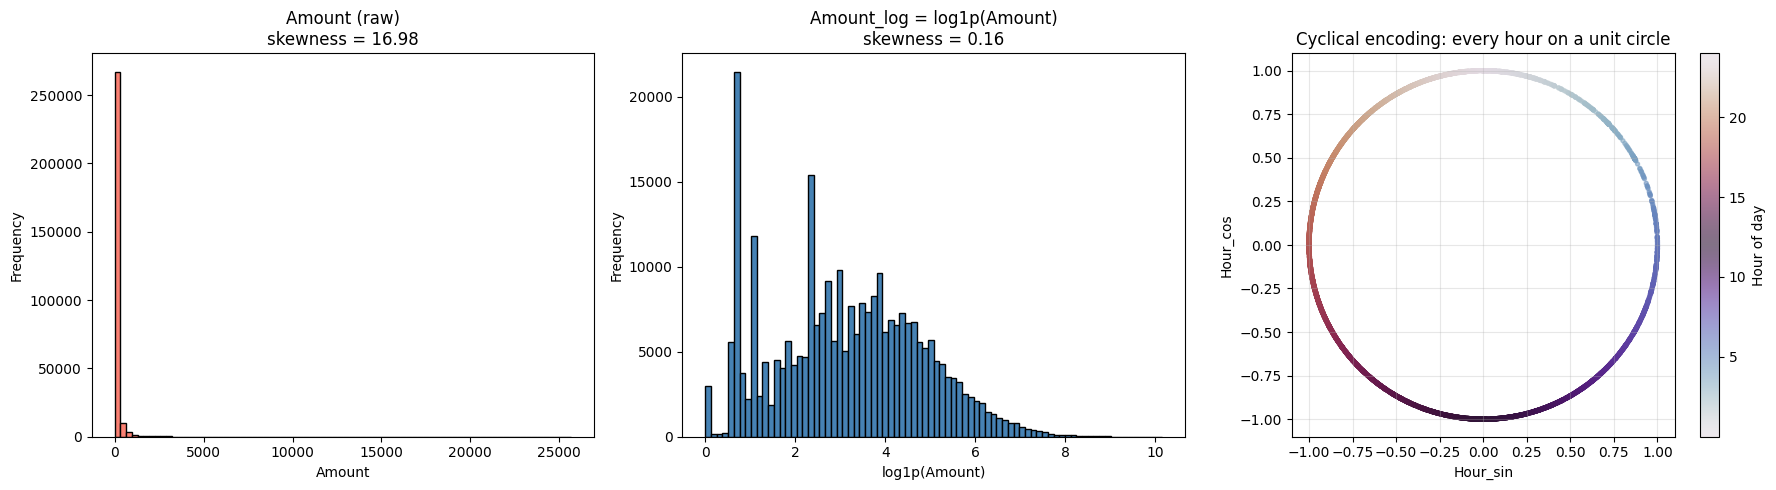

Skewness of Amount:        before = 16.98
Skewness of Amount_log:    after  = 0.16
Hour 0 and Hour 23 are now neighbours on the unit circle
(they sit at almost the same (sin, cos) coordinates).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Amount BEFORE log ---
axes[0].hist(df_raw['Amount'], bins=80, color='salmon', edgecolor='black')
axes[0].set_title(f'Amount (raw)\nskewness = {df_raw["Amount"].skew():.2f}')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# --- Plot 2: Amount AFTER log1p ---
axes[1].hist(df['Amount_log'], bins=80, color='steelblue', edgecolor='black')
axes[1].set_title(f'Amount_log = log1p(Amount)\nskewness = {df["Amount_log"].skew():.2f}')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Frequency')

# --- Plot 3: Hour_sin vs Hour_cos forms a unit circle ---
sample = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
hour_for_colour = (df_raw.loc[sample.index, 'Time'] % SECONDS_PER_DAY) / 3600
sc = axes[2].scatter(sample['Hour_sin'], sample['Hour_cos'],
                     c=hour_for_colour, cmap='twilight', s=8, alpha=0.6)
axes[2].set_xlabel('Hour_sin')
axes[2].set_ylabel('Hour_cos')
axes[2].set_title('Cyclical encoding: every hour on a unit circle')
axes[2].set_aspect('equal')
axes[2].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[2], label='Hour of day')

plt.tight_layout()
plt.show()

print(f"Skewness of Amount:        before = {df_raw['Amount'].skew():.2f}")
print(f"Skewness of Amount_log:    after  = {df['Amount_log'].skew():.2f}")
print("Hour 0 and Hour 23 are now neighbours on the unit circle")
print("(they sit at almost the same (sin, cos) coordinates).")

*### Interpretation*

The Amount(raw) graph shows the original transaction amount distribution. Most transactions have very small amounts, while only a few transactions have very large amounts. This makes the graph highly skewed to the right, with many extreme outliers. This skew may affect the model training because the large values can dominate the learning process.

The Amount_log = log1p(Amount) graph shows the transaction amount after applying the log transformation. Compared to the original graph, the distribution becomes more balanced and spread more evenly. The skewness value also decreases greatly from 16.98 to 0.16. This transformation helps reduce the impact of extreme values and makes the data easier for the machine learning model to learn.

The Cyclical encoding graph shows the cyclical encoding applied to the Time feature using sine and cosine values. The circular shape represents how time repeats in a cycle, where hour 23 is close to hour 0. This method helps preserve the relationship between neighbouring hours instead of treating them as completely separate values. It may help the model identify fraud patterns that happen during certain times of the day.


# Stage 0b = Imbalance Handling

### Checking class distribution

In [ ]:
print("Class counts:")
print(df['Class'].value_counts())

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64


### Split Data


*   Split data into training and test set (80/20)
*   Training set is used for learning while test set is used for final evaluation
*   stratify=y keeps the same fraud rate in both splits

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (226980, 31)
Test set shape: (56746, 31)


### Scale Data

Ensure all features have similar scale (Prevent one feature dominating others)

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled = scaler.transform(X_test)         # transform only ← never fit on test

#### Determining which method is more suitable (SMOTE or class weight)

In [ ]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (average_precision_score, f1_score,
                              precision_score, recall_score, roc_auc_score)

# Generate SMOTE-resampled training set (for comparison only)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Variant 1: Unweighted baseline (no imbalance handling — naive)
lr_naive = LogisticRegression(random_state=42, max_iter=1000)
lr_naive.fit(X_train_scaled, y_train)

# Variant 2: Class weighting only
lr_weighted = LogisticRegression(class_weight='balanced',
                                  random_state=42,
                                  max_iter=1000)
lr_weighted.fit(X_train_scaled, y_train)

# Variant 3: SMOTE only
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)

# Get predictions and probabilities on the SAME test set
y_pred_naive = lr_naive.predict(X_test_scaled)
y_proba_naive = lr_naive.predict_proba(X_test_scaled)[:, 1]

y_pred_weighted = lr_weighted.predict(X_test_scaled)
y_proba_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]

y_pred_smote = lr_smote.predict(X_test_scaled)
y_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

# Build comparison table
comparison = pd.DataFrame({
    'Unweighted (naive)': [
        average_precision_score(y_test, y_proba_naive),
        f1_score(y_test, y_pred_naive),
        precision_score(y_test, y_pred_naive, zero_division=0),
        recall_score(y_test, y_pred_naive),
        roc_auc_score(y_test, y_proba_naive),
    ],
    'Class Weighting': [
        average_precision_score(y_test, y_proba_weighted),
        f1_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_weighted, zero_division=0),
        recall_score(y_test, y_pred_weighted),
        roc_auc_score(y_test, y_proba_weighted),
    ],
    'SMOTE': [
        average_precision_score(y_test, y_proba_smote),
        f1_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_smote, zero_division=0),
        recall_score(y_test, y_pred_smote),
        roc_auc_score(y_test, y_proba_smote),
    ]
}, index=['AUC-PR', 'F1', 'Precision', 'Recall', 'ROC-AUC']).round(4)

print("=== Imbalance Handling Comparison (Logistic Regression) ===")
print(comparison)

print(f"\n=== Improvement from Class Weighting over Unweighted ===")
print((comparison['Class Weighting'] - comparison['Unweighted (naive)']).round(4))

print(f"\n=== Difference (SMOTE - Class Weighting) ===")
print((comparison['SMOTE'] - comparison['Class Weighting']).round(4))

=== Imbalance Handling Comparison (Logistic Regression) ===
           Unweighted (naive)  Class Weighting   SMOTE
AUC-PR                 0.7036           0.6807  0.6779
F1                     0.7000           0.1049  0.1003
Precision              0.8615           0.0558  0.0532
Recall                 0.5895           0.8737  0.8737
ROC-AUC                0.9561           0.9636  0.9619

=== Improvement from Class Weighting over Unweighted ===
AUC-PR      -0.0229
F1          -0.5951
Precision   -0.8057
Recall       0.2842
ROC-AUC      0.0075
dtype: float64

=== Difference (SMOTE - Class Weighting) ===
AUC-PR      -0.0028
F1          -0.0046
Precision   -0.0026
Recall       0.0000
ROC-AUC     -0.0017
dtype: float64


*### Interpretation*

Since this system is designed for credit card fraud detection, the model focuses more on achieving high recall and PR-AUC performance to reduce false negatives and ensure that fraudulent transactions are not missed. Although SMOTE was tested to balance the dataset, its a bit worse than simple class weighting. Therefore, class weighting was chosen because it improved the model’s focus on the minority fraud class without generating synthetic samples, while still maintaining strong fraud detection performance.

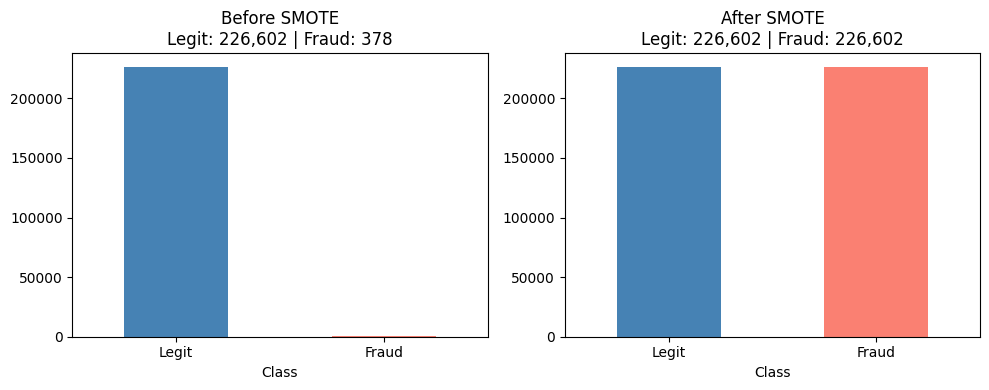

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title(f'Before SMOTE\nLegit: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

# After SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title(f'After SMOTE\nLegit: {(y_train_smote==0).sum():,} | Fraud: {(y_train_smote==1).sum():,}')
axes[1].set_xticklabels(['Legit', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

*### Interpretation*

The first graph shows the class distribution before applying SMOTE. The dataset is highly imbalanced because there are 226,602 legitimate transactions but only 378 fraud transactions. This imbalance may cause the model to focus more on the majority class and ignore fraud cases because predicting "legit" minimises overall loss.

The second graph shows the class distribution after applying SMOTE. The fraud class was increased using synthetic samples until both classes became balanced, with 226,602 transactions each. The samples are generated by interpolating between existing fraud points and their k-nearest neighbours in feature space. This helps the model learn fraud patterns better and improves its ability to detect fraudulent transactions during training.

#### Compute class weight as final choice

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute weights
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced',
                                classes=classes,
                                y=y_train) # use training label data (answers)

class_weights = dict(zip(classes, weights))

# Clean print
print("Class Weights:")
for cls, weight in class_weights.items():
    label = 'Legit (0)' if cls == 0 else 'Fraud (1)'
    print(f"  {label}: {weight:.4f}")

Class Weights:
  Legit (0): 0.5008
  Fraud (1): 300.2381


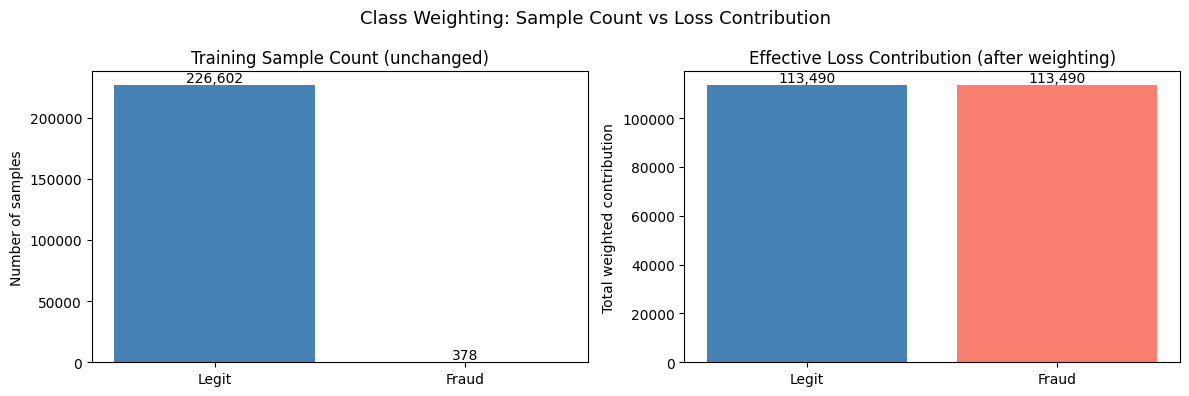

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: training set composition (unchanged by weighting)
n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
axes[0].bar(['Legit', 'Fraud'], [n_legit, n_fraud], color=['steelblue', 'salmon'])
axes[0].set_title('Training Sample Count (unchanged)')
axes[0].set_ylabel('Number of samples')
for i, v in enumerate([n_legit, n_fraud]):
    axes[0].annotate(f'{v:,}', xy=(i, v), ha='center', va='bottom')

# Right: effective loss contribution after weighting
legit_contrib = n_legit * class_weights[0]
fraud_contrib = n_fraud * class_weights[1]
axes[1].bar(['Legit', 'Fraud'], [legit_contrib, fraud_contrib], color=['steelblue', 'salmon'])
axes[1].set_title('Effective Loss Contribution (after weighting)')
axes[1].set_ylabel('Total weighted contribution')
for i, v in enumerate([legit_contrib, fraud_contrib]):
    axes[1].annotate(f'{v:,.0f}', xy=(i, v), ha='center', va='bottom')

plt.suptitle('Class Weighting: Sample Count vs Loss Contribution', fontsize=13)
plt.tight_layout()
plt.show()

*### Interpretation*

The figure shows the effect of class weighting in Logistic Regression. The left graph displays the original training data distribution, where legitimate transactions greatly outnumber fraud transactions, creating a highly imbalanced dataset. The right graph shows the effective weighted contribution after applying class weighting. Although the number of fraud samples remains the same, the fraud class is given higher importance during training so that both classes contribute more equally to the model. This helps the model focus more on detecting fraud transactions and reduces the chance of missing fraud cases.

# Stage A = Baseline Model: Logistic Regression

### Feature Set

In [ ]:
# Use all 31 features (V1–V28 + Hour_sin + Hour_cos + Amount_log)
# X_train_scaled and X_test_scaled were already prepared in Cell 34
# using RobustScaler fit on training data only.

selected_features = X_train.columns.tolist()

X_train_top_scaled = X_train_scaled
X_test_top_scaled  = X_test_scaled

print(f"Total features used: {len(selected_features)}")
print(f"Features: {selected_features}")
print(f"X_train shape: {X_train_top_scaled.shape}")
print(f"X_test shape:  {X_test_top_scaled.shape}")

Total features used: 31
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour_sin', 'Hour_cos', 'Amount_log']
X_train shape: (226980, 31)
X_test shape:  (56746, 31)


### Baseline Training

In [ ]:
# Baseline model: Logistic Regression with balanced class weights
lr_baseline = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='lbfgs'
)

lr_baseline.fit(X_train_top_scaled, y_train)

# Predictions on the held-out test set
y_pred_base  = lr_baseline.predict(X_test_top_scaled)
y_proba_base = lr_baseline.predict_proba(X_test_top_scaled)[:, 1]

# Inspect learned coefficients
coef_table = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr_baseline.coef_[0].round(4),
    'Direction': ['↑ fraud risk' if c > 0 else '↓ fraud risk'
                  for c in lr_baseline.coef_[0]]
})
print("Intercept:", round(lr_baseline.intercept_[0], 4))
print()
print("Learned coefficients (on scaled features):")
print(coef_table.to_string(index=False))

coef_table_sorted = coef_table.reindex(
    coef_table['Coefficient'].abs().sort_values(ascending=False).index
)
print("\nTop 10 features by |coefficient|:")
print(coef_table_sorted.head(10).to_string(index=False))

Intercept: -3.8379

Learned coefficients (on scaled features):
   Feature  Coefficient    Direction
        V1       0.9332 ↑ fraud risk
        V2      -0.4533 ↓ fraud risk
        V3       0.1365 ↑ fraud risk
        V4       1.6584 ↑ fraud risk
        V5       0.2454 ↑ fraud risk
        V6      -0.2341 ↓ fraud risk
        V7       0.1308 ↑ fraud risk
        V8      -0.3645 ↓ fraud risk
        V9      -0.6576 ↓ fraud risk
       V10      -1.2716 ↓ fraud risk
       V11       0.9512 ↑ fraud risk
       V12      -1.3655 ↓ fraud risk
       V13      -0.3621 ↓ fraud risk
       V14      -1.2841 ↓ fraud risk
       V15      -0.3430 ↓ fraud risk
       V16      -0.6056 ↓ fraud risk
       V17      -0.7628 ↓ fraud risk
       V18      -0.3643 ↓ fraud risk
       V19       0.2952 ↑ fraud risk
       V20      -0.1008 ↓ fraud risk
       V21       0.1987 ↑ fraud risk
       V22       0.7023 ↑ fraud risk
       V23      -0.0207 ↓ fraud risk
       V24       0.2436 ↑ fraud risk
       V25  

*### Interpretation*

The coefficient magnitudes show which features dominate the linear decision boundary after RobustScaler normalisation. V4 has the strongest effect (+1.66). The high V4 values push the prediction toward fraud while V12, V14, and V10 are the strongest negative drivers (each around −1.3), meaning low values of these features push toward fraud. V11 and V1 also contribute strongly in the positive direction (+0.95 and +0.93).

Notably, V4 and V11 ranked only 9th and 8th by univariate correlation with Class, yet they emerge as two of the strongest predictors once the model can combine them with the other features. This demonstrates why correlation-based feature selection would have been a poor choice the joint multivariate fit recovers signal that single-feature ranking misses. The five features highlighted in the EDA (V17, V14, V12, V10, V16) still carry meaningful weight, but they are not the full story.

Amount_log has a modest positive effect (+0.22), consistent with fraud transactions skewing slightly toward smaller amounts. The cyclical time features (Hour_sin = −0.37, Hour_cos = +0.21) are modest in magnitude, indicating time-of-day is a weak linear predictor on its own though it may still carry non-linear signal that tree-based models in Stage B could exploit.

The intercept of −3.84 is strongly negative, meaning the model defaults to predicting legit unless multiple features show unusual values simultaneously. `class_weight='balanced'` was applied to counteract the imbalance. Without it, the effective decision threshold would sit so high that fraud recall would collapse.

### Metric Table

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report)

metrics_baseline = {
    'Accuracy':          accuracy_score(y_test, y_pred_base),
    'Precision (fraud)': precision_score(y_test, y_pred_base, zero_division=0),
    'Recall (fraud)':    recall_score(y_test, y_pred_base),
    'F1 (fraud)':        f1_score(y_test, y_pred_base),
    'ROC-AUC':           roc_auc_score(y_test, y_proba_base),
    'AUC-PR (primary)':  average_precision_score(y_test, y_proba_base),
}

metrics_df = pd.DataFrame(metrics_baseline, index=['Logistic Regression (baseline)']).T.round(4)
metrics_df.columns = ['Score']
print("=== Stage A — Baseline Metrics ===")
print(metrics_df)

print("\n=== Per-class classification report ===")
print(classification_report(y_test, y_pred_base,
                            target_names=['Legit (0)', 'Fraud (1)'],
                            digits=4))

=== Stage A — Baseline Metrics ===
                    Score
Accuracy           0.9750
Precision (fraud)  0.0558
Recall (fraud)     0.8737
F1 (fraud)         0.1049
ROC-AUC            0.9636
AUC-PR (primary)   0.6807

=== Per-class classification report ===
              precision    recall  f1-score   support

   Legit (0)     0.9998    0.9752    0.9873     56651
   Fraud (1)     0.0558    0.8737    0.1049        95

    accuracy                         0.9750     56746
   macro avg     0.5278    0.9245    0.5461     56746
weighted avg     0.9982    0.9750    0.9859     56746



### Visualization

True Negatives  (legit correctly passed):   55,247
False Positives (legit flagged as fraud):   1,404
False Negatives (fraud MISSED):             12
True Positives  (fraud caught):             83


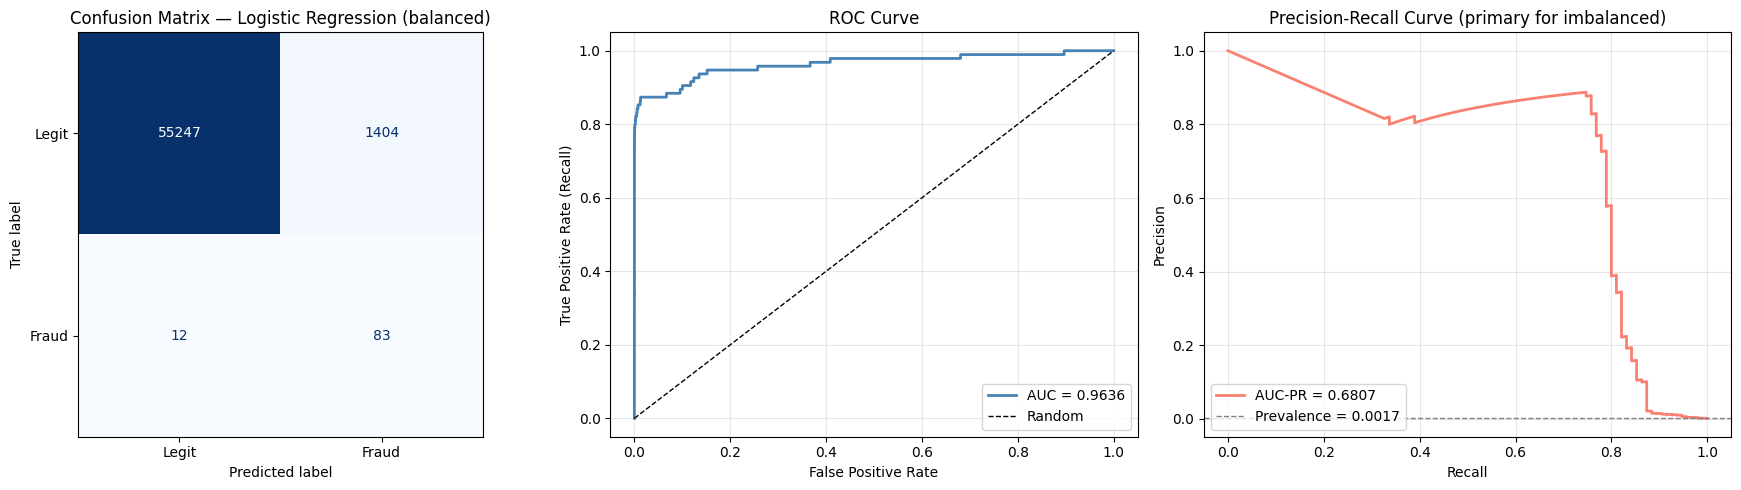

In [ ]:
from sklearn.metrics import (ConfusionMatrixDisplay, roc_curve,
                              precision_recall_curve)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d'
)
axes[0].set_title('Confusion Matrix — Logistic Regression (balanced)')

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (legit correctly passed):   {tn:,}")
print(f"False Positives (legit flagged as fraud):   {fp:,}")
print(f"False Negatives (fraud MISSED):             {fn}")
print(f"True Positives  (fraud caught):             {tp}")

# --- Plot 2: ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba_base)
roc_auc = roc_auc_score(y_test, y_proba_base)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# --- Plot 3: Precision-Recall curve (primary) ---
prec, rec, _ = precision_recall_curve(y_test, y_proba_base)
auc_pr = average_precision_score(y_test, y_proba_base)
baseline_rate = y_test.mean()
axes[2].plot(rec, prec, color='salmon', lw=2, label=f'AUC-PR = {auc_pr:.4f}')
axes[2].axhline(baseline_rate, color='gray', linestyle='--', lw=1,
                label=f'Prevalence = {baseline_rate:.4f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (primary for imbalanced)')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

*### Interpretation*

The confusion matrix shows where the model succeeds and where it fails. The biggest concern is the False Negative, since each missed fraud cost a lot of money in this context. The balance between False Positive and False Negative reflects the class weighting decision. The model is configured toward catching fraud (high recall) at the cost of more false alarms (lower precision).

The ROC curve plots True Positive Rate against False Positive Rate across all decision thresholds. The metric is effected by class imbalance, which the false positive rate stays very low simply because the legitimate class is so large that even thousands of false positive barely move the rate.

The precision recall curve shows that the curve sits far above the dashed grey line, which confirms that the model has learned real fraud signal. The curve shape reveals the precision-recall trade-off. Precision stays reasonably high at low to moderate recall, the drops sharply as recall approaches 1. This means that the model can catch most fraud, but catching last few fraud cases requires accepting many false positives.

# Stage B = Ensemble / Intermediate Model - XG Boosting

In [ ]:
!pip install xgboost -q

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

### Scale_pos_weight calculation

In [ ]:
# tells XGBoost how much to up-weight the positive (fraud) class in the loss
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print('Class 0 (legit) count:', (y_train == 0).sum())
print('Class 1 (fraud) count:', (y_train == 1).sum())
print('scale_pos_weight    :', round(scale_pos_weight, 2))

Class 0 (legit) count: 226602
Class 1 (fraud) count: 378
scale_pos_weight    : 599.48


### Class weight visualisation

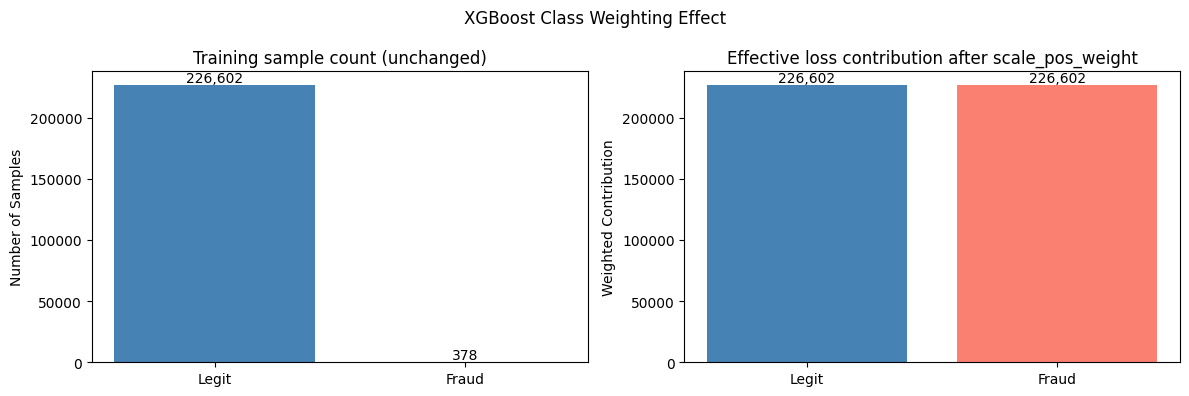

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original class distribution
n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()

axes[0].bar(
    ['Legit', 'Fraud'],
    [n_legit, n_fraud],
    color=['steelblue', 'salmon']
)

axes[0].set_title('Training sample count (unchanged)')
axes[0].set_ylabel('Number of Samples')

for i, v in enumerate([n_legit, n_fraud]):
    axes[0].annotate(f'{v:,}',
                     xy=(i, v),
                     ha='center',
                     va='bottom')

# Effective contribution after scale_pos_weight
legit_contrib = n_legit
fraud_contrib = n_fraud * scale_pos_weight

axes[1].bar(
    ['Legit', 'Fraud'],
    [legit_contrib, fraud_contrib],
    color=['steelblue', 'salmon']
)

axes[1].set_title('Effective loss contribution after scale_pos_weight')
axes[1].set_ylabel('Weighted Contribution')

for i, v in enumerate([legit_contrib, fraud_contrib]):
    axes[1].annotate(f'{v:,.0f}',
                     xy=(i, v),
                     ha='center',
                     va='bottom')

plt.suptitle('XGBoost Class Weighting Effect')
plt.tight_layout()
plt.show()

##### Creating XGBoost model

In [ ]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Reference: untuned default XGBoost, same CV, same metric
default_cv_aucpr = cross_val_score(
    xgb_base, X_train, y_train, scoring='average_precision', cv=cv, n_jobs=-1
).mean()
print('Untuned default XGBoost — mean CV AUC-PR:', round(default_cv_aucpr, 4))

Untuned default XGBoost — mean CV AUC-PR: 0.8474


### Hyperparameter search

In [ ]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring='average_precision',   # AUC-PR
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Train on unscaled feature; tree model
xgb_search.fit(X_train, y_train)

print('\nBest parameters:')
print(xgb_search.best_params_)
print('\nBest CV AUC-PR :', round(xgb_search.best_score_, 4))
print('Untuned AUC-PR :', round(default_cv_aucpr, 4))
print('Gain from tuning:', round(xgb_search.best_score_ - default_cv_aucpr, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV AUC-PR : 0.8452
Untuned AUC-PR : 0.8474
Gain from tuning: -0.0021


#### Intepretation

The gain from tuning is -0.0021, which is practically zero and is within the cross-validation noise while the fold-to-fold swing in AUC-PR is almost certainly larger than 0.002 (0.8452 vs 0.8474) which is statistically still a tie, not a proof that the tuning hurt.

The default XGBoost was already near-optimal for this data and a 10-iteration random search over a conservative grid didn't beat it. A reasonable explanation is that XGBoost already works well right out of the box.

In [ ]:
# Hyperparameter search evidence
search_results = pd.DataFrame(xgb_search.cv_results_)
evidence_table = search_results[[
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'param_subsample', 'param_colsample_bytree',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

print('=== Hyperparameter Search Evidence (sorted by rank) ===')
print(evidence_table.head(10).to_string(index=False))

=== Hyperparameter Search Evidence (sorted by rank) ===
 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree  mean_test_score  std_test_score  rank_test_score
                200                4                 0.10              1.0                     0.8         0.845228        0.030124                1
                300                4                 0.05              1.0                     1.0         0.838388        0.029465                2
                300                3                 0.10              1.0                     1.0         0.830862        0.027568                3
                300                3                 0.05              1.0                     1.0         0.791633        0.033550                4
                100                5                 0.05              0.8                     0.8         0.772673        0.028986                5
                300                4              

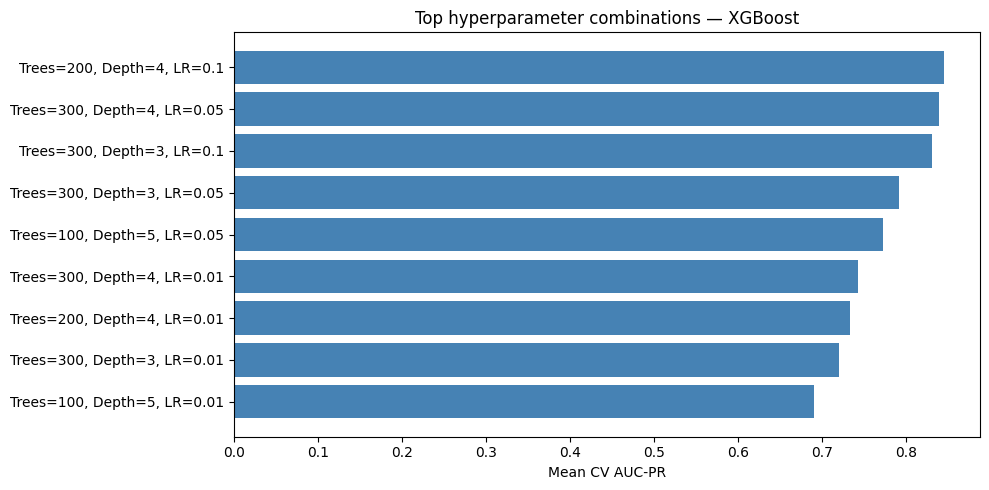

In [ ]:
top_search = evidence_table.head(10).copy()
top_search['Setting'] = ('Trees=' + top_search['param_n_estimators'].astype(str)
                         + ', Depth=' + top_search['param_max_depth'].astype(str)
                         + ', LR=' + top_search['param_learning_rate'].astype(str))

plt.figure(figsize=(10, 5))
plt.barh(top_search['Setting'], top_search['mean_test_score'], color='steelblue')
plt.xlabel('Mean CV AUC-PR')
plt.title('Top hyperparameter combinations — XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
xgb_model = xgb_search.best_estimator_

# Probablities of held out test set
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# TEST

Predictions at the default 0.5 threshold (.predict())

In [ ]:
y_pred_xgb = xgb_model.predict(X_test) # default 0.5 decision threshold

metrics_xgb = {
    'Precision (fraud)': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall (fraud)':    recall_score(y_test, y_pred_xgb),
    'F1 (fraud)':        f1_score(y_test, y_pred_xgb),
    'ROC-AUC':           roc_auc_score(y_test, y_proba_xgb),
    'AUC-PR (primary)':  average_precision_score(y_test, y_proba_xgb),
}

metrics_xgb_df = pd.DataFrame(metrics_xgb,
                              index=['XGBoost (thr=0.50)']).T.round(4)
metrics_xgb_df.columns = ['Score']
print('=== XGBoost metrics (default 0.50 threshold) ===')
print(metrics_xgb_df)
print('\nNote: AUC-PR and ROC-AUC are threshold-independent; precision/recall/F1\n'
      'reflect the default 0.50 operating point.')

print('\n=== Per-class classification report ===')
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Legit (0)', 'Fraud (1)'], digits=4))

=== XGBoost metrics (default 0.50 threshold) ===
                    Score
Precision (fraud)  0.7576
Recall (fraud)     0.7895
F1 (fraud)         0.7732
ROC-AUC            0.9674
AUC-PR (primary)   0.8093

Note: AUC-PR and ROC-AUC are threshold-independent; precision/recall/F1
reflect the default 0.50 operating point.

=== Per-class classification report ===
              precision    recall  f1-score   support

   Legit (0)     0.9996    0.9996    0.9996     56651
   Fraud (1)     0.7576    0.7895    0.7732        95

    accuracy                         0.9992     56746
   macro avg     0.8786    0.8945    0.8864     56746
weighted avg     0.9992    0.9992    0.9992     56746



#### Intepretation

Accuracy is 99.92% but it is uninformative for this dataset. The metrics that are meaningful are recall, precision and AUC-PR. The model catches 78.95% of fraud (recall) while 75.76% of it fraud alerts are correct (precision), giving an F1 score of 0.7732. The primary metric (AUC-PR) obtained 0.8093 which vastly exceeds the baseline prevalence rate (how often fraud occurs) is 95 / 56,746 * 100 = 0.17%, This confirms the models is picking up real patterns rather than making random guesses.

True Negatives  (legit passed):   56,627
False Positives (legit flagged):  24
False Negatives (fraud MISSED):   20
True Positives  (fraud caught):   75


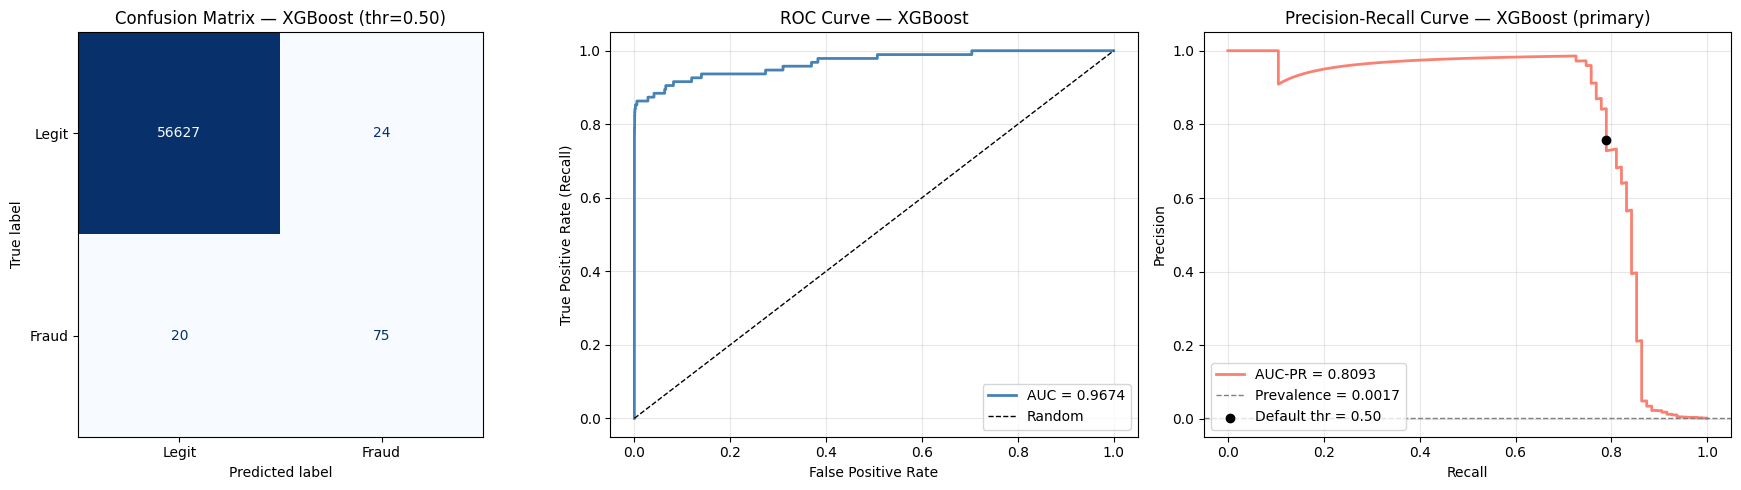

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix at the chosen threshold
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Legit', 'Fraud']).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Confusion Matrix — XGBoost (thr=0.50)')

tn, fp, fn, tp = cm_xgb.ravel()
print(f'True Negatives  (legit passed):   {tn:,}')
print(f'False Positives (legit flagged):  {fp:,}')
print(f'False Negatives (fraud MISSED):   {fn}')
print(f'True Positives  (fraud caught):   {tp}')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_proba_xgb):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — XGBoost')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall curve (primary for imbalanced)
prec, rec, _ = precision_recall_curve(y_test, y_proba_xgb)
auc_pr = average_precision_score(y_test, y_proba_xgb)
baseline_rate = y_test.mean()
axes[2].plot(rec, prec, color='salmon', lw=2, label=f'AUC-PR = {auc_pr:.4f}')
axes[2].axhline(baseline_rate, color='gray', linestyle='--', lw=1,
                label=f'Prevalence = {baseline_rate:.4f}')
axes[2].scatter([recall_score(y_test, y_pred_xgb)],
                [precision_score(y_test, y_pred_xgb, zero_division=0)],
                color='black', zorder=5, label='Default thr = 0.50')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — XGBoost (primary)')
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Intepretation

From the confusion matrix shows the trade-off concretely where 20 frauds were missed (False Negatives, the costly error in this domain) against 24 false alarms. The ROC curve hugs the top-left (ROC-AUC = 0.9674), but ROC is still optimistic even under extreme imbalance because the legit class keeps the false-positive rate tiny even when there are false alarms which is the reason we use AUC-PR as primary metric.

#### Impact of imbalance handling on XGBoost

In [ ]:
best_params = dict(xgb_search.best_params_)

# using the same params with no class weighting
xgb_noweight = XGBClassifier(
    **best_params,
    objective='binary:logistic', eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_noweight.fit(X_train, y_train)
proba_nw = xgb_noweight.predict_proba(X_test)[:, 1]
pred_nw = (proba_nw >= 0.5).astype(int)

# show weighted model at default 0.5 for comparison
pred_w_05 = (y_proba_xgb >= 0.5).astype(int)

compare = pd.DataFrame({
    'No weighting (thr=0.5)': [
        average_precision_score(y_test, proba_nw),
        recall_score(y_test, pred_nw),
        precision_score(y_test, pred_nw, zero_division=0),
        f1_score(y_test, pred_nw),
    ],
    'scale_pos_weight (thr=0.5)': [
        average_precision_score(y_test, y_proba_xgb),
        recall_score(y_test, pred_w_05),
        precision_score(y_test, pred_w_05, zero_division=0),
        f1_score(y_test, pred_w_05),
    ],
}, index=['AUC-PR', 'Recall', 'Precision', 'F1']).round(4)

print('=== Impact of imbalance handling on XGBoost ===')
print(compare)

=== Impact of imbalance handling on XGBoost ===
           No weighting (thr=0.5)  scale_pos_weight (thr=0.5)
AUC-PR                     0.7940                      0.8093
Recall                     0.7158                      0.7895
Precision                  0.9577                      0.7576
F1                         0.8193                      0.7732


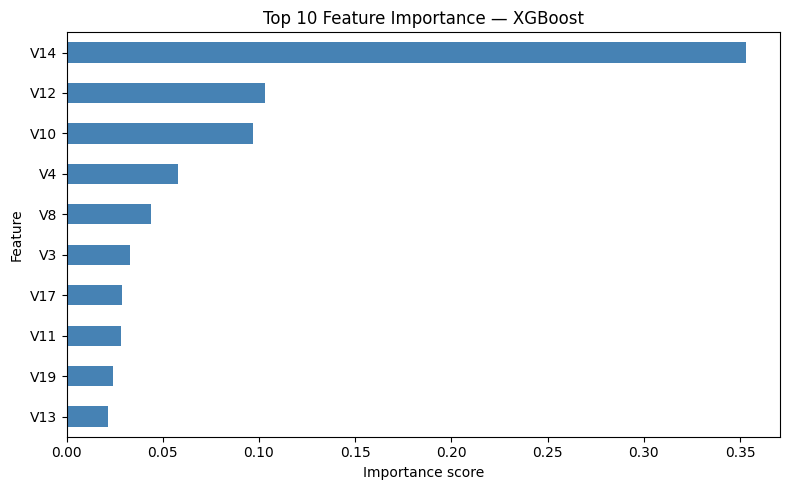

V14    0.353112
V12    0.103103
V10    0.096684
V4     0.057999
V8     0.044069
V3     0.032997
V17    0.028573
V11    0.028224
V19    0.024239
V13    0.021350
dtype: float32


In [ ]:
feature_importance = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

top_10 = feature_importance.head(10)

plt.figure(figsize=(8, 5))
top_10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importance — XGBoost')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(top_10)

#### Intepretation

The feature importance chart shows that V14 is the most influential feature for fraud detection (~35.31% contribution of the model's decision-makin importance) followed by V12 and V10 which are the second and third most important features, while the remaining features have a smaller impact. This indicates that XGBoost relies heavily on a few key variables to distinguish fraudulent transactions form legitimate ones.

# Stage C - Deep Learning Model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

#### Set random seed

In [ ]:
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

#### Build MLP

In [ ]:
mlp_model = Sequential([
    Input(shape=(X_train_top_scaled.shape[1],)),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
    )

history = mlp_model.fit(
    X_train_top_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=2048,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 0.7964 - pr_auc: 0.0402 - roc_auc: 0.6813 - val_loss: 0.6061 - val_pr_auc: 0.3274 - val_roc_auc: 0.9589
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4371 - pr_auc: 0.1587 - roc_auc: 0.8909 - val_loss: 0.4440 - val_pr_auc: 0.6160 - val_roc_auc: 0.9714
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3291 - pr_auc: 0.2897 - roc_auc: 0.9410 - val_loss: 0.3181 - val_pr_auc: 0.7186 - val_roc_auc: 0.9755
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2752 - pr_auc: 0.3233 - roc_auc: 0.9552 - val_loss: 0.2454 - val_pr_auc: 0.7523 - val_roc_auc: 0.9774
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2521 - pr_auc: 0.3494 - roc_auc: 0.9546 - val_loss: 0.2005 - val_pr_auc: 0.7328 - val_roc_auc: 0.9784
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1964 - pr_auc: 0.4126 - roc_auc: 0.9767 - val_loss: 0.1636 - val_pr_auc: 0.7518 - val_roc_auc: 0.9794
Epoch 7/15
89/89 ━━━━━━━━━

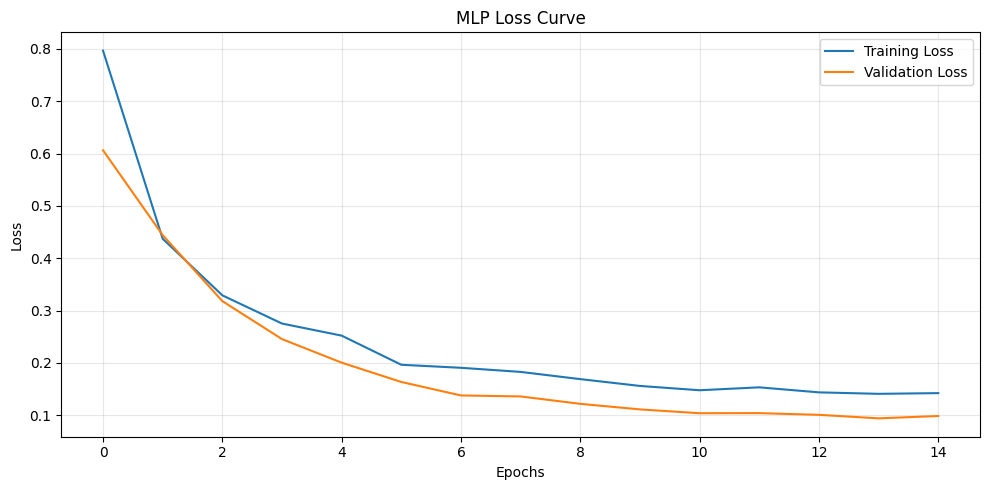

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("MLP Loss Curve")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Intepretation

This loss curve shows that the MLP model is learning properly because both the training loss and validation loss decrease from the first epoch until the final epoch, meaning the model is improving over time. The validation loss also stays slightly lower than the trainig loss and does not suddenly increase (no clear sign of overfitting). Overall, the model training looks stable and the model is learning useful patterns from the data.

#### Predict Test Data

In [ ]:
y_proba_mlp = mlp_model.predict(X_test_top_scaled)

threshold = 0.5
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


#### Evaluation Metric

In [ ]:
metric_mlp = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision (fraud)": precision_score(y_test, y_pred_mlp, zero_division=0),
    "Recall (fraud)": recall_score(y_test, y_pred_mlp),
    "F1 (fraud)": f1_score(y_test, y_pred_mlp),
    "ROC-AUC": roc_auc_score(y_test, y_proba_mlp),
    "AUC-PR (primary)": average_precision_score(y_test, y_proba_mlp)
}

metric_mlp_df = pd.DataFrame(metric_mlp, index=["MLP (class weight)"]).T.round(4)
metric_mlp_df.columns = ["Score"]

print("=== Stage C - MLP metrics ===")
print(metric_mlp_df)

print("\n=== Per-class classification report ===")
print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=["Legit (0)", "Fraud (1)"],
    digits=4
))

=== Stage C - MLP metrics ===
                    Score
Accuracy           0.9794
Precision (fraud)  0.0661
Recall (fraud)     0.8632
F1 (fraud)         0.1228
ROC-AUC            0.9608
AUC-PR (primary)   0.6614

=== Per-class classification report ===
              precision    recall  f1-score   support

   Legit (0)     0.9998    0.9796    0.9896     56651
   Fraud (1)     0.0661    0.8632    0.1228        95

    accuracy                         0.9794     56746
   macro avg     0.5329    0.9214    0.5562     56746
weighted avg     0.9982    0.9794    0.9881     56746



#### Intepretation

The result shows that the MLP model achieved an accuracy of 97.94%, indicating that most transaction were classified correctly but since the dataset is highly imbalanced, accuracy is not the most important metric.

For fraud detection, the model achieved a recall of (86.32%) meaning it successfully detected most fraudulent transactions and onlu missed a small fraction of fraudulent cases. However, the precision is only 6.61%, which means many legitimate transaction were incorrectly flagged as fraud resulting in a large number of false positives. This explains why the low F1-score of 0.1266 (poor balance between precision and recall).

THe ROC-AUC scored 0.9608 showing that the model has a strong ability to distinguish between legitimate and fraudulent transaction overall but the AUC-PR scored 0.6614, whihc is more important for this imbalanced fraud detection dataset, is lower thatn the XGBoost model. This suggest s thtat although the MLP can identify many fraud cases, it is less effective at maintaining precision when detecting the minority fraud class

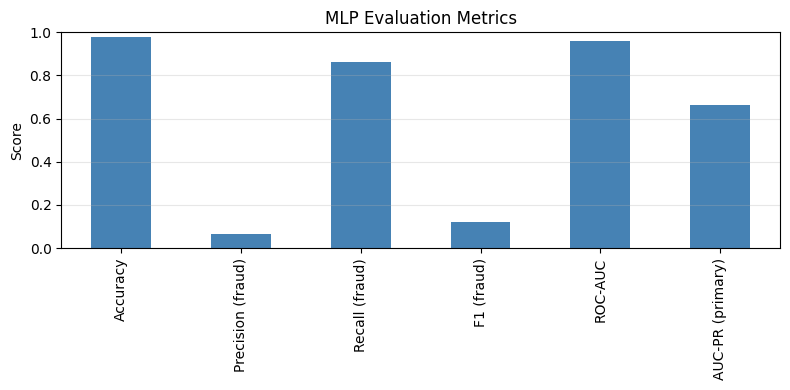

In [ ]:
plt.figure(figsize=(8, 4))

metric_mlp_df["Score"].plot(kind="bar", color="steelblue")
plt.title("MLP Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

True Negatives  (legit correctly passed):   55,493
False Positives (legit flagged as fraud):   1,158
False Negatives (fraud MISSED):             13
True Positives  (fraud caught):             82


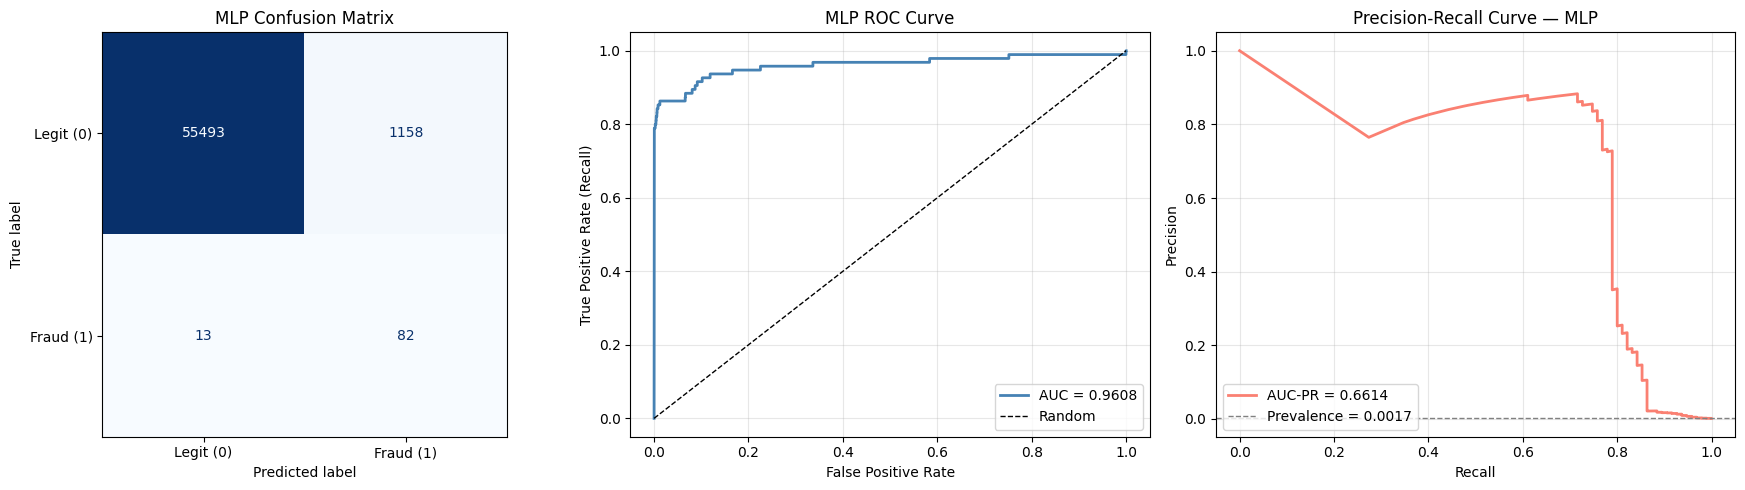

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

ConfusionMatrixDisplay(
    cm_mlp,
    display_labels=["Legit (0)", "Fraud (1)"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

axes[0].set_title("MLP Confusion Matrix")

tn, fp, fn, tp = cm_mlp.ravel()
print(f"True Negatives  (legit correctly passed):   {tn:,}")
print(f"False Positives (legit flagged as fraud):   {fp:,}")
print(f"False Negatives (fraud MISSED):             {fn}")
print(f"True Positives  (fraud caught):             {tp}")

# ROC Curve
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp)

axes[1].plot(fpr_mlp, tpr_mlp, color="steelblue", lw=2,
             label=f"AUC = {roc_auc_mlp:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("MLP ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# PR Curve
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test, y_proba_mlp)
auc_pr_mlp = average_precision_score(y_test, y_proba_mlp)
baseline_rate = y_test.mean()

axes[2].plot(rec_mlp, prec_mlp, color="salmon", lw=2,
             label=f"AUC-PR = {auc_pr_mlp:.4f}")
axes[2].axhline(baseline_rate, color="gray", linestyle="--", lw=1,
                label=f"Prevalence = {baseline_rate:.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve — MLP")
axes[2].legend(loc="lower left")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Intepretation

The confusion matrix shows that the MLP model correctly classified 55,493 legitimate transactions (True Negatives) and successfully detected 82 fraud transactions (True Positives). However, it incorrectly flagged 1,158 legitimate transactions as fraud (False Positives) and missed 13 fraud casas( False Negatives) which indicates that the model is very aggressive in detecting fraud, resulting in high recall but also a large number of false alarms.

Next chart show the ROC curve is very close to the top-left corner and achives a ROC-AUC score of 0.9608 indicating excelent class separation ability. This means the model can effectively distinguish between fraudulent and legitimate transactions across different classification thresholds. Overall, the ROC curve suggests that the model learned useful patterns from the data.

Lastly, the Precision-Recall curve shows that the model maintains high recall but struggles to maintain precision as recall increases. The AUC-PR which scored 0.6614 indicates moderate fraud detection performance on this highly imbalanced dataset. Althought the model successfully detects most fraud cases, precision decreases significantly at higher recall levels due to the large number of false positives (legit as fraud). This is consistent with the confusion matrix and explains why the precision score is much lower than the recall score.

# Final Model Comparison (Stage A vs B vs C)

=== Final Model Comparison - held-out test set ===
                   Logistic Regression (thr=0.50)  XGBoost (thr=0.50)  \
Accuracy                                   0.9750              0.9992   
Precision (fraud)                          0.0558              0.7576   
Recall (fraud)                             0.8737              0.7895   
F1 (fraud)                                 0.1049              0.7732   
ROC-AUC                                    0.9636              0.9674   
AUC-PR (primary)                           0.6807              0.8093   

                   MLP (thr=0.50)  
Accuracy                   0.9794  
Precision (fraud)          0.0661  
Recall (fraud)             0.8632  
F1 (fraud)                 0.1228  
ROC-AUC                    0.9608  
AUC-PR (primary)           0.6614  

Best model by primary metric (AUC-PR): XGBoost (thr=0.50)


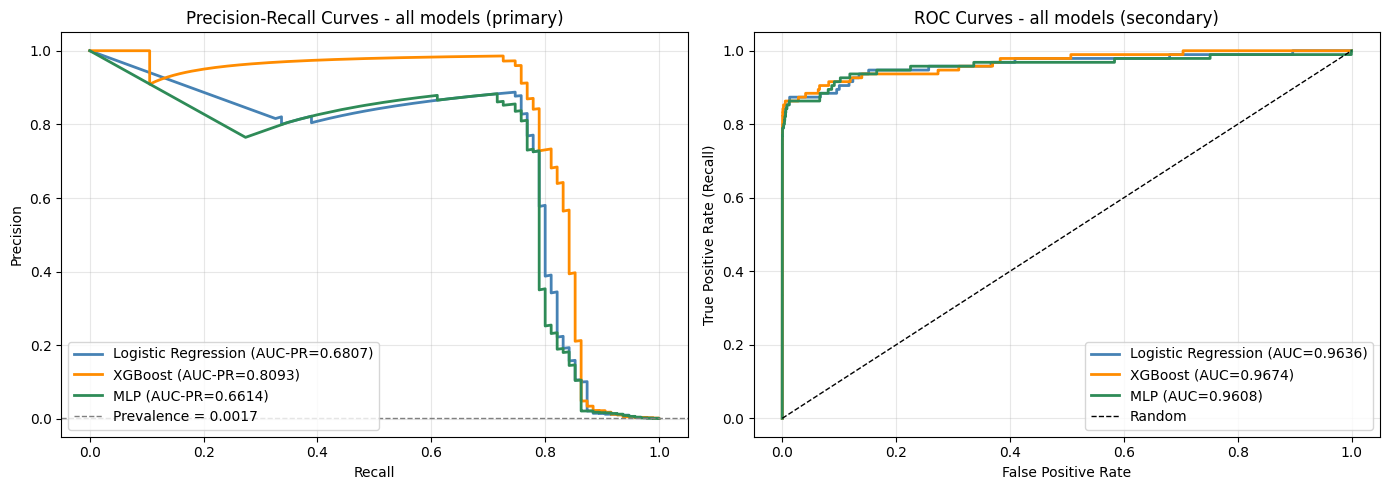

In [ ]:
lr_threshold   = 0.50
best_threshold = 0.50
mlp_threshold  = 0.50

def metric_row(y_true, y_pred, y_proba):
    """Standard metric set as a Series so every model shares one index."""
    return pd.Series({
        'Accuracy':          accuracy_score(y_true, y_pred),
        'Precision (fraud)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (fraud)':    recall_score(y_true, y_pred),
        'F1 (fraud)':        f1_score(y_true, y_pred),
        'ROC-AUC':           roc_auc_score(y_true, y_proba),
        'AUC-PR (primary)':  average_precision_score(y_true, y_proba),
    })

final_table = pd.DataFrame({
    f'Logistic Regression (thr={lr_threshold:.2f})': metric_row(y_test, y_pred_base, y_proba_base),
    f'XGBoost (thr={best_threshold:.2f})':           metric_row(y_test, y_pred_xgb,  y_proba_xgb),
    f'MLP (thr={mlp_threshold:.2f})':                metric_row(y_test, y_pred_mlp,  y_proba_mlp),
}).round(4)

print('=== Final Model Comparison - held-out test set ===')
print(final_table)

best_model = final_table.loc['AUC-PR (primary)'].idxmax()
print(f"\nBest model by primary metric (AUC-PR): {best_model}")

# === Overlaid PR and ROC curves ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# np.ravel guards against the MLP probabilities being a (n, 1) Keras array
models = [
    ('Logistic Regression', np.ravel(y_proba_base), 'steelblue'),
    ('XGBoost',             np.ravel(y_proba_xgb),  'darkorange'),
    ('MLP',                 np.ravel(y_proba_mlp),  'seagreen'),
]

# PR curves (primary)
baseline_rate = y_test.mean()
for name, proba, colour in models:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(r, p, color=colour, lw=2, label=f'{name} (AUC-PR={ap:.4f})')
axes[0].axhline(baseline_rate, color='gray', linestyle='--', lw=1,
                label=f'Prevalence = {baseline_rate:.4f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves - all models (primary)')
axes[0].legend(loc='lower left')
axes[0].grid(alpha=0.3)

# ROC curves (secondary)
for name, proba, colour in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color=colour, lw=2, label=f'{name} (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curves - all models (secondary)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Intepretation

From the PR curve chart, we can see XGBoost is the best model on the main metric. Since fraud makes up just ~0.17% of the test set, we rank the models by AUC-PR and XGBoost wins with 0.8093, ahead of Logistic Regression (0.6807) and the MLP (0.6614). In the left plot, the orange XGBoost curve stays above the other two across almost the entire recall range (kept at ~0.97 precision up to roughly 0.7 recall before it falls off). LR and the MLP follow each other closely and stay lower.

The ROC plot is misleading here, and that's worth pointing out. All three models land at about 0.96-0.97 ROC-AUC, and their curves nearly overlap. With this much imbalance, the large legitimate class controls the false-positive rate. Even a weak model looks strong and all three appears to be similar. we can really tell them apart from the PR curves which is why we use AUC-PR as the main metric and while ROC only as a backup.

At the 0.50 threshold, the three act very differently. XGBoost scored on precision (~0.76), recall (~0.79), F1 (~0.77) while LR and MLP, both class-weighted leaned hard towards recall (~0.87 and ~0.86) but falls apart on precision (0.056 and 0.066 giving the F1 score of around 0.10-0.12) meaning nearly all the fraud they flag is a false alarm.

In conclusion, XGboost wins the threshold independent metric by a lot and already works well at the default threshold. LR stays as the baseline and MLP isn't worth it because of the added complexity even though it has the lower AUC-PR, it is no better then the basic linear model.

Not only that, the precision, recall and F1 only describe at 0.50 threshold point. The deployment threshold should be tuned based on the cost of missing real fraud versus running an unnecesary investigation.